### Import all the necessary libraries

In [3]:
import tensorflow as tf
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer ,WordNetLemmatizer
import string



I0000 00:00:1781858501.239784    4817 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781858501.240823    4817 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /home/rsh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/rsh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/rsh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Loading the dataset 

In [5]:
data = pd.read_csv("/home/rsh/Desktop/projects /IMDB Dataset.csv")

In [6]:
### Text preprocessing 

punctuations = string.punctuation
stopwords = nltk.corpus.stopwords.words('english')
lm = WordNetLemmatizer()
## stopwords

In [ ]:
### Text preprocessing

punctuations = string.punctuation
lm = WordNetLemmatizer()

# Step 1: Define NEGATION_WORDS first
NEGATION_WORDS = {
    "not", "no", "never", "nor", "neither", "nobody", "nothing", "nowhere",
    "n't", "cant", "cannot", "wont", "dont", "doesnt", "didnt",
    "isnt", "wasnt", "werent", "havent", "hasnt", "hadnt",
    "shouldnt", "wouldnt", "couldnt", "mightnt", "mustnt"
}

# Step 2: Build filtered stopwords (keeping negations)
stopwords_filtered = set(
    w for w in nltk.corpus.stopwords.words('english')
    if w not in NEGATION_WORDS
)

# Step 3: Define negate_sequence
def negate_sequence(text, window=4):
    words = text.split()
    result = []
    negation_counter = 0
    for word in words:
        if word.lower() in NEGATION_WORDS:
            negation_counter = window
            result.append(word)
            continue
        if negation_counter > 0:
            result.append("NOT_" + word)
            negation_counter -= 1
        else:
            result.append(word)
    return " ".join(result)

# Step 4: Define clean_text
def clean_text(text):
    only_text = BeautifulSoup(text, "html.parser").get_text()
    text = "".join([char.lower() for char in only_text if char not in punctuations])
    tokens = word_tokenize(text)
    filtered = " ".join([lm.lemmatize(token) for token in tokens
                         if token not in stopwords_filtered])
    return negate_sequence(filtered)

# Step 5: NOW apply to data
X = data['review'].apply(lambda x: clean_text(x))
Y = data['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# Step 6: Sanity check BEFORE proceeding
print(clean_text("This movie is worth it"))
# → "movie worth"

print(clean_text("This movie is not worth it"))
# → "not NOT_worth NOT_it NOT_movie"  (4 words tagged)

In [8]:
X= data['review'].apply(lambda x : clean_text(x))
Y = data['sentiment'].apply(lambda x :1 if x =='positive' else 0)

### Tokenizing Sentence 

In [9]:
X

0        one reviewer mentioned watching 1 oz episode y...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically there family little boy jake think t...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job wasnt NOT_creativ...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    im going disagree previous comment side maltin...
49999    no NOT_one NOT_expects NOT_star NOT_trek NOT_m...
Name: review, Length: 50000, dtype: object

In [10]:
tokenized = [word_tokenize(sentence) for sentence in X.to_list() ]

In [11]:
tokenized

[['one',
  'reviewer',
  'mentioned',
  'watching',
  '1',
  'oz',
  'episode',
  'youll',
  'hooked',
  'right',
  'exactly',
  'happened',
  'methe',
  'first',
  'thing',
  'struck',
  'oz',
  'brutality',
  'unflinching',
  'scene',
  'violence',
  'set',
  'right',
  'word',
  'go',
  'trust',
  'not',
  'NOT_show',
  'NOT_faint',
  'NOT_hearted',
  'NOT_timid',
  'NOT_show',
  'NOT_pull',
  'no',
  'NOT_punch',
  'NOT_regard',
  'NOT_drug',
  'NOT_sex',
  'NOT_violence',
  'NOT_hardcore',
  'NOT_classic',
  'NOT_use',
  'NOT_wordit',
  'NOT_called',
  'NOT_oz',
  'NOT_nickname',
  'NOT_given',
  'NOT_oswald',
  'NOT_maximum',
  'NOT_security',
  'NOT_state',
  'NOT_penitentary',
  'NOT_focus',
  'NOT_mainly',
  'NOT_emerald',
  'NOT_city',
  'NOT_experimental',
  'NOT_section',
  'NOT_prison',
  'NOT_cell',
  'NOT_glass',
  'NOT_front',
  'NOT_face',
  'NOT_inwards',
  'NOT_privacy',
  'not',
  'NOT_high',
  'NOT_agenda',
  'NOT_em',
  'NOT_city',
  'NOT_home',
  'NOT_manyaryans'

In [12]:
X.to_list()[0]

'one reviewer mentioned watching 1 oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust not NOT_show NOT_faint NOT_hearted NOT_timid NOT_show NOT_pull no NOT_punch NOT_regard NOT_drug NOT_sex NOT_violence NOT_hardcore NOT_classic NOT_use NOT_wordit NOT_called NOT_oz NOT_nickname NOT_given NOT_oswald NOT_maximum NOT_security NOT_state NOT_penitentary NOT_focus NOT_mainly NOT_emerald NOT_city NOT_experimental NOT_section NOT_prison NOT_cell NOT_glass NOT_front NOT_face NOT_inwards NOT_privacy not NOT_high NOT_agenda NOT_em NOT_city NOT_home NOT_manyaryans NOT_muslim NOT_gangsta NOT_latino NOT_christian NOT_italian NOT_irish NOT_moreso NOT_scuffle NOT_death NOT_stare NOT_dodgy NOT_dealing NOT_shady NOT_agreement never NOT_far NOT_awayi NOT_would NOT_say NOT_main NOT_appeal NOT_show NOT_due NOT_fact NOT_go NOT_show wouldnt NOT_dare NOT_forget NOT_pretty NOT_picture NOT_painted NOT_mainstream NOT_audience NOT

In [13]:
tokenized[0]

['one',
 'reviewer',
 'mentioned',
 'watching',
 '1',
 'oz',
 'episode',
 'youll',
 'hooked',
 'right',
 'exactly',
 'happened',
 'methe',
 'first',
 'thing',
 'struck',
 'oz',
 'brutality',
 'unflinching',
 'scene',
 'violence',
 'set',
 'right',
 'word',
 'go',
 'trust',
 'not',
 'NOT_show',
 'NOT_faint',
 'NOT_hearted',
 'NOT_timid',
 'NOT_show',
 'NOT_pull',
 'no',
 'NOT_punch',
 'NOT_regard',
 'NOT_drug',
 'NOT_sex',
 'NOT_violence',
 'NOT_hardcore',
 'NOT_classic',
 'NOT_use',
 'NOT_wordit',
 'NOT_called',
 'NOT_oz',
 'NOT_nickname',
 'NOT_given',
 'NOT_oswald',
 'NOT_maximum',
 'NOT_security',
 'NOT_state',
 'NOT_penitentary',
 'NOT_focus',
 'NOT_mainly',
 'NOT_emerald',
 'NOT_city',
 'NOT_experimental',
 'NOT_section',
 'NOT_prison',
 'NOT_cell',
 'NOT_glass',
 'NOT_front',
 'NOT_face',
 'NOT_inwards',
 'NOT_privacy',
 'not',
 'NOT_high',
 'NOT_agenda',
 'NOT_em',
 'NOT_city',
 'NOT_home',
 'NOT_manyaryans',
 'NOT_muslim',
 'NOT_gangsta',
 'NOT_latino',
 'NOT_christian',
 'NOT_

### Word2Vec

In [15]:
!pip install gensim

Defaulting to user installation because normal site-packages is not writeable


In [16]:
from gensim.models import Word2Vec
W2V_model = Word2Vec(
    sentences = tokenized,
    vector_size= 200, 
    window =5,
    min_count=2,
    sg=0,
    epochs = 8
)

In [17]:
print("NOT_worth" in W2V_model.wv)  # Should be True
print(W2V_model.wv.most_similar("NOT_worth"))  # Should cluster with negative words

True
[('NOT_worthy', 0.557876706123352), ('NOT_fp', 0.5350364446640015), ('NOT_worthwhile', 0.5218809843063354), ('NOT_filmographywell', 0.5082437992095947), ('NOT_regret', 0.4866955280303955), ('NOT_wellworth', 0.4827001094818115), ('NOT_donemy', 0.4785598814487457), ('NOT_suggest', 0.4763602912425995), ('NOT_recommended', 0.4710836708545685), ('NOT_forward', 0.4658840000629425)]


In [18]:
W2V_model.wv['good'].shape

(200,)

In [19]:
W2V_model.wv.most_similar(5)

[('NOT_alike', 0.5659359097480774),
 ('NOT_reminded', 0.5324404835700989),
 ('NOT_elsewhere', 0.5187662839889526),
 ('NOT_embarrassed', 0.50709468126297),
 ('NOT_prefer', 0.505154550075531),
 ('NOT_sorry', 0.5006889700889587),
 ('NOT_hate', 0.4998883605003357),
 ('NOT_fake', 0.4990127384662628),
 ('NOT_ie', 0.49355924129486084),
 ('NOT_scared', 0.4926127791404724)]

In [20]:
X

0        one reviewer mentioned watching 1 oz episode y...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically there family little boy jake think t...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job wasnt NOT_creativ...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    im going disagree previous comment side maltin...
49999    no NOT_one NOT_expects NOT_star NOT_trek NOT_m...
Name: review, Length: 50000, dtype: object

In [21]:
type(X)

pandas.core.series.Series

In [22]:
X = np.array(X.to_list())

In [23]:
X

array(['one reviewer mentioned watching 1 oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust not NOT_show NOT_faint NOT_hearted NOT_timid NOT_show NOT_pull no NOT_punch NOT_regard NOT_drug NOT_sex NOT_violence NOT_hardcore NOT_classic NOT_use NOT_wordit NOT_called NOT_oz NOT_nickname NOT_given NOT_oswald NOT_maximum NOT_security NOT_state NOT_penitentary NOT_focus NOT_mainly NOT_emerald NOT_city NOT_experimental NOT_section NOT_prison NOT_cell NOT_glass NOT_front NOT_face NOT_inwards NOT_privacy not NOT_high NOT_agenda NOT_em NOT_city NOT_home NOT_manyaryans NOT_muslim NOT_gangsta NOT_latino NOT_christian NOT_italian NOT_irish NOT_moreso NOT_scuffle NOT_death NOT_stare NOT_dodgy NOT_dealing NOT_shady NOT_agreement never NOT_far NOT_awayi NOT_would NOT_say NOT_main NOT_appeal NOT_show NOT_due NOT_fact NOT_go NOT_show wouldnt NOT_dare NOT_forget NOT_pretty NOT_picture NOT_painted NOT_mainstream NOT_audie

In [24]:
Y= np.array(Y.to_list())


In [25]:
Y

array([1, 1, 1, ..., 0, 0, 0], shape=(50000,))

In [26]:
###Train test split

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test , Y_train, Y_test =  train_test_split(X , Y ,test_size=0.2 ,random_state =42)


### Text vectorization 

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM ,Embedding , Bidirectional, TextVectorization



In [29]:
vocab_size =20000
max_len= 200
vectorized_layer = TextVectorization(
    max_tokens = vocab_size,
    output_mode = 'int',
    output_sequence_length = max_len,
    

)

E0000 00:00:1781858660.677027    4817 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781858660.699705    4817 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [30]:
vectorized_layer.adapt(X_train)

In [31]:
vocab = np.array(vectorized_layer.get_vocabulary())

In [32]:
vocab[:10]

array(['', '[UNK]', 'notmovie', 'not', 'notfilm', 'notone', 'movie',
       'notlike', 'film', 'no'], dtype='<U19')

### BUILDING EMBEDDING

In [33]:
W2V_model.vector_size

200

In [34]:
vocab = vectorized_layer.get_vocabulary()
emb_dim = W2V_model.vector_size
embedding_matrix = np.zeros((len(vocab), emb_dim)) ###  20000 X 200 matrix

for i, word in enumerate(vocab):
    if word in W2V_model.wv:
        embedding_matrix[i] = W2V_model.wv[word]


In [35]:
embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.15120097, -0.00390814,  0.11312097, ..., -0.10091109,
        -0.18205118, -0.02510685],
       [-0.02410162,  0.11794489,  0.11064614, ..., -0.10756576,
        -0.14272366, -0.11819138],
       [-0.09972925,  0.00981545,  0.1915473 , ..., -0.1145796 ,
        -0.06951518,  0.03162289]], shape=(20000, 200))

  ### Step-2: Initialize Keras Embedding with these weights

In [48]:
embedding_layer = Embedding(
    input_dim=len(vocab),
    output_dim=emb_dim,
    weights= [embedding_matrix],
    trainable= True   # or True, if you want to fine-tune
)


### Building bidirectional LSTM Model 

In [37]:
model = Sequential()

model.add(tf.keras.Input(shape=(1,), dtype=tf.string))

model.add(vectorized_layer)
model.add(embedding_layer)
model.add(tf.keras.layers.SpatialDropout1D(0.3))
model.add(Bidirectional(LSTM(100, dropout = 0.3,activation='tanh')))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 200)       │     4,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 200)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200)            │       240,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,253,729 (16.23 MB)

 Trainable params: 253,729 (991.13 KB)

 Non-trainable params: 4,000,000 (15.26 MB)

In [38]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [39]:
print(type(X_train))
print(X_train.dtype if hasattr(X_train, 'dtype') else "No dtype")

print(type(Y_train))
print(Y_train.dtype if hasattr(Y_train, 'dtype') else "No dtype")

<class 'numpy.ndarray'>
<U14176
<class 'numpy.ndarray'>
int64


In [40]:

X_train_tf = tf.constant(X_train, dtype=tf.string)
X_test_tf = tf.constant(X_test, dtype=tf.string)

In [41]:
print(X_train.shape)
print(X_train.dtype)
print(type(X_train[0]))
print(X_train[0][:100])

print(Y_train.shape)
print(Y_train.dtype)

(40000,)
<U14176
<class 'numpy.str_'>
thats kept asking many fight screaming match swearing general mayhem permeate 84 minute comparison a
(40000,)
int64


In [42]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(X_train_tf,Y_train,validation_data=(X_test_tf,Y_test),batch_size=32,epochs=20,
                    callbacks=[early_stop]
                    )

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 39ms/step - accuracy: 0.6723 - loss: 0.6021 - val_accuracy: 0.7415 - val_loss: 0.5080
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.7215 - loss: 0.5438 - val_accuracy: 0.7529 - val_loss: 0.4870
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.7275 - loss: 0.5287 - val_accuracy: 0.7498 - val_loss: 0.4873
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.7351 - loss: 0.5179 - val_accuracy: 0.7457 - val_loss: 0.4868
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.7419 - loss: 0.5060 - val_accuracy: 0.7593 - val_loss: 0.4717
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.7441 - loss: 0.5043 - val_accuracy: 0.7597 - val_loss: 0.4685
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.7485 - loss: 0.5001 - val_accuracy: 0.7603 - val_loss: 0.4694
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.7517 -

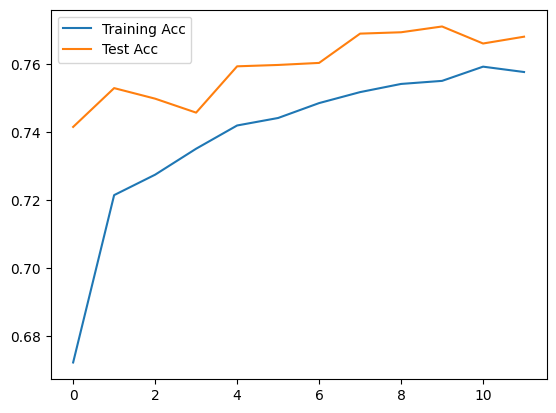

In [43]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='Training Acc')
plt.plot(history.history['val_accuracy'],label='Test Acc')
plt.legend()
plt.show()

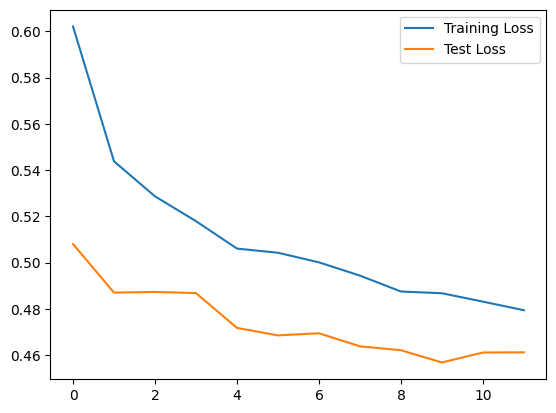

In [44]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Test Loss')
plt.legend()
plt.show()

In [45]:
print(clean_text("This movie is worth it"))
print(clean_text("This movie is not worth it"))

movie worth
movie not NOT_worth


## Prediction on Random Text 

In [46]:
test_text = "Not worth it "

pred = model.predict(
    tf.constant([clean_text(test_text)], dtype=tf.string)
)



if pred[0][0] > 0.5:
    print("Positive Sentiment")
    print("Score:", pred[0][0])
else:
    print("Negative Sentiment")
    print("Score:", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Positive Sentiment
Score: 0.63234955


In [47]:
test_text_1 = "worth it "

pred = model.predict(
    tf.constant([clean_text(test_text_1)], dtype=tf.string)
)



if pred[0][0] > 0.5:
    print("Positive Sentiment")
    print("Score:", pred[0][0])
else:
    print("Negative Sentiment")
    print("Score:", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Positive Sentiment
Score: 0.67320263


In [ ]:
y_pred = model.predict(X_test_tf)
y_pred_binary = np.where(y_pred > 0.5, 1, 0)
y_pred_binary

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


array([[0],
       [1],
       [0],
       ...,
       [1],
       [0],
       [1]], shape=(10000, 1))

In [ ]:
y_pred_binary.shape

(10000, 1)

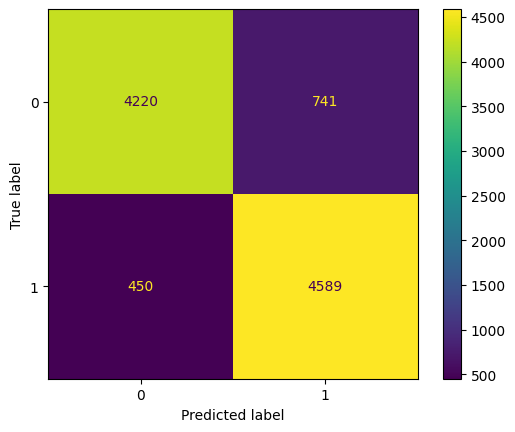

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(Y_test,y_pred_binary))
disp.plot()

In [ ]:
print(classification_report(Y_test, y_pred_binary))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88      4961
           1       0.86      0.91      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

